# 从合成图像拟合净电荷

## tl;dr
使用不同净电荷的同条件期望图像构建模板，并在独立探测器采样上拟合。

## Context & Methods

这里的数值只是软件演示，模拟粒子数太少，不足以给出实验检出限。正式判据为零电荷下假阳性率 ≤5%、备择电荷下检出率 ≥95%。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
from droplet_shadow import load_config, simulate
from droplet_shadow.analysis import fit_charge, calibrated_detection_limit
from droplet_shadow.detector import make_images
base = load_config(ROOT / 'examples/baseline-geant4.yaml').with_updates(run={'n_simulated': 400, 'exposure_electrons': 400})
charges = [-1e7, 0, 1e7]
models = {q: simulate(base.with_updates(charge={'q_e': q}), ROOT / f'results/notebook_fit_Q{q:+.0f}') for q in charges}
templates = {q: models[q].images['expected'] for q in charges}
independent = make_images(models[1e7].config, models[1e7].hits, np.random.default_rng(7654321))['observed']
fit = fit_charge(independent, templates)
print('Known Q=1e7 e; fitted grid Q=', fit.q_e, 'scores=', fit.scores)

Known Q=1e7 e; fitted grid Q= 10000000.0 scores= {-10000000.0: 32.94911233086643, 0.0: 31.8413445261589, 10000000.0: 16.822321198179367}


## Results

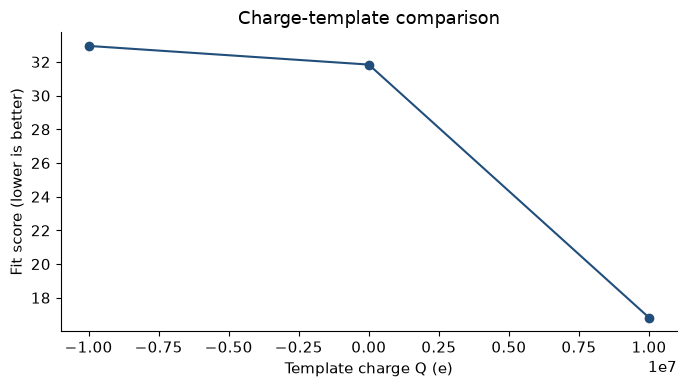

In [3]:
fig, ax = plt.subplots()
ax.plot(charges, [fit.scores[q] for q in charges], marker='o', color='#214e7a')
ax.set(xlabel='Template charge Q (e)', ylabel='Fit score (lower is better)', title='Charge-template comparison')
fig.tight_layout(); plt.show()

### 检出限伪实验链路测试

下面每种真实电荷只做 4 次独立束流/输运/探测器采样，仅检查校准算法能运行；不把所得检出率用于实验设计。

In [4]:
from droplet_shadow.sensitivity import detection_calibration
paths = {q: ROOT / f'results/notebook_fit_Q{q:+.0f}' for q in charges}
calibration = detection_calibration(base.with_updates(run={'n_simulated':100, 'exposure_electrons':100}),
                                    paths, ROOT / 'results/notebook_limit_demo',
                                    repetitions=4, fit_nuisance=False)
print('Null threshold:', calibration.threshold, 'empirical FPR:', calibration.false_positive_rate)
print('Power by Q:', calibration.power_by_charge, 'minimum |Q|:', calibration.minimum_detectable_abs_q_e)
print('Charge-grid bias:', calibration.charge_bias_by_true_q_e)
print('Held-out interval coverage:', calibration.interval_coverage_by_true_q_e)

Null threshold: 0.0063315494145186335 empirical FPR: 0.0
Power by Q: {-10000000.0: 0.0, 10000000.0: 0.0} minimum |Q|: None
Charge-grid bias: {-10000000.0: 20000000.0, 0.0: -10000000.0, 10000000.0: -5000000.0}
Held-out interval coverage: {-10000000.0: 0.0, 0.0: 1.0, 10000000.0: 0.5}


## Takeaways

电荷推断必须和相同材料、源与探测器条件下的图像比较。真正的最低可探测电荷需要高统计量独立模板和至少约 100 次独立曝光，并以经验阈值校准假阳性率。